# Predicting Leaf Morphology through Wavelet transforms and...


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def process_image(image):
    plt.figure()
    # Apply bilateral filter
    bilateral_filtered_image = cv2.bilateralFilter(image, 9, 75, 75)

    # Apply binary thresholding
    _, binary_image = cv2.threshold(bilateral_filtered_image, 250, 255, cv2.THRESH_BINARY)

    # Invert the image to make the leaf white and background black
    binary_image = cv2.bitwise_not(binary_image)

    # Detect edges using Canny
    edges = cv2.Canny(binary_image, 200, 400)  # Adjust thresholds if needed

    # Find contours
    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Ensure contours were found
    if not contours:
        print("No contours found")
        return None

    # Get the largest contour (assuming it's the leaf contour)
    contour = max(contours, key=cv2.contourArea)

    # Convert contour to numpy array
    contour = contour[:, 0, :].astype(np.float32)

    # Plot the original contours
    plt.imshow(binary_image, cmap='gray')
    plt.title("Original Contour")
    plt.axis("off")
    plt.plot(contour[:, 0], contour[:, 1], color='green', label='Original Contour')

    # Find the centroid (center of the leaf)
    M = cv2.moments(contour)
    center = (int(M["m10"] / M["m00"]), int(M["m01"] / M["m00"]))

    # Calculate the orientation of the stem (angle)
    # Fit an ellipse to the contour (to get the orientation)
    ellipse = cv2.fitEllipse(contour)
    angle = ellipse[2]  # This is the rotation angle of the ellipse

    print("Angle before adjustment:", angle)
    angle = (angle + 90) % 180  # Adjust the angle to be in the range [0, 180)

    # Rotate the contour to align the stem with 0 degrees
    rotation_matrix = cv2.getRotationMatrix2D(center, 180 + angle, 1.0)  # Rotate counter-clockwise
    rotated_contour = cv2.transform(np.array([contour]), rotation_matrix)[0]

    # Convert the rotated contour to polar coordinates (r, theta) with more data points
    polar_coords = []
    for point in rotated_contour:
        x, y = point
        r = np.sqrt((x - center[0]) ** 2 + (y - center[1]) ** 2)  # Distance from the center
        theta = np.arctan2(y - center[1], x - center[0])  # Angle in radians
        polar_coords.append((r, theta))
    

    
    # Plot the polar coordinates of the rotated contour
    radii, angles = zip(*polar_coords)
    plt.figure(figsize=(6, 6))
    ax = plt.subplot(111, projection='polar')
    ax.plot(angles, radii, '.', label='Polar Coordinates of Rotated Contour')
    ax.set_title("Polar Coordinates of Rotated Contour")
    plt.show()

    # Plot theta vs r for all polar coordinates and don't connect the first and last with a line
    plt.plot(angles, radii,'.')
    plt.title("Theta vs R")
    plt.xlabel("Theta (radians)")
    plt.ylabel("R")
    plt.show()
    
    return {
        "M": M,
        "angle": angle,
        "angles": angles,
        "ax": ax,
        "bilateral_filtered_image": bilateral_filtered_image,
        "binary_image": binary_image,
        "center": center,
        "contour": contour,
        "contours": contours,
        "edges": edges,
        "ellipse": ellipse,
        "image": image,
        "polar_coords": polar_coords,
        "radii": radii,
        "rotated_contour": rotated_contour,
        "rotation_matrix": rotation_matrix
    }


Angle before adjustment: 29.269628524780273


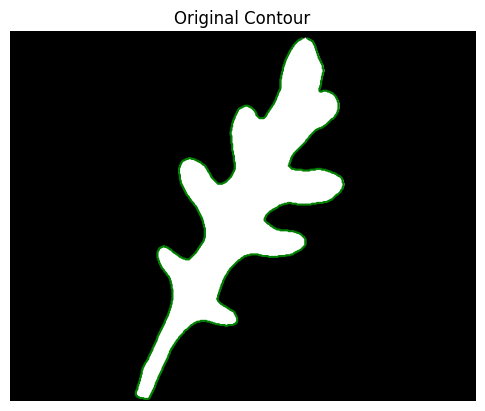

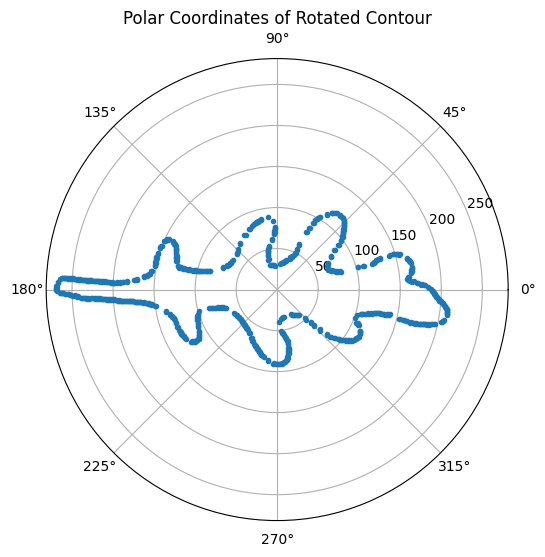

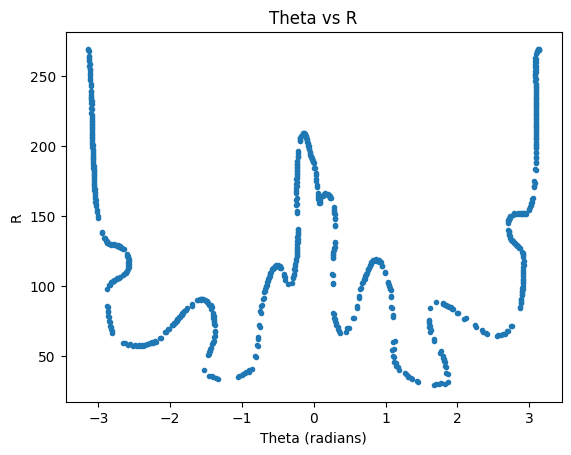

Angle before adjustment: 1.1681358814239502


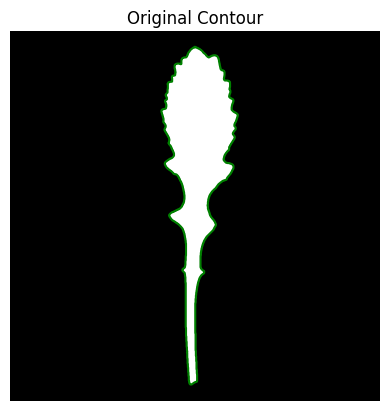

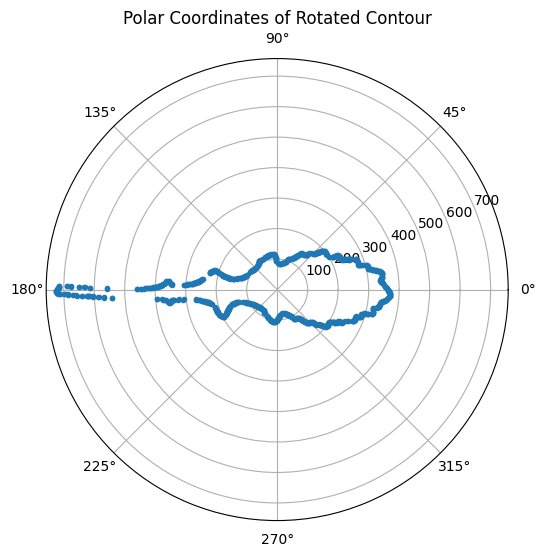

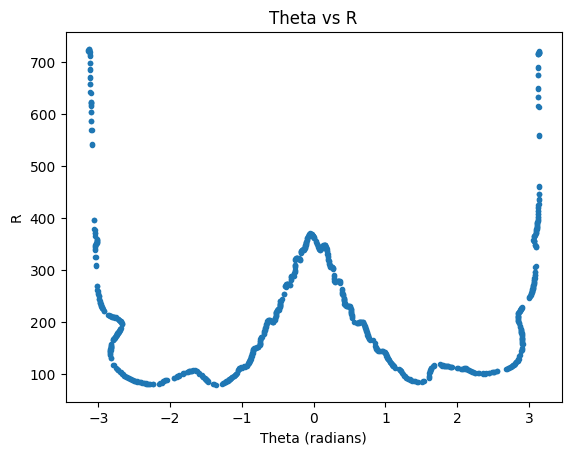

Angle before adjustment: 0.9691129326820374


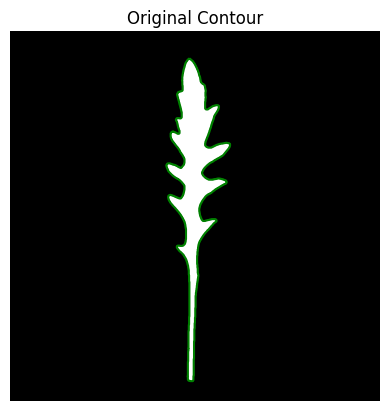

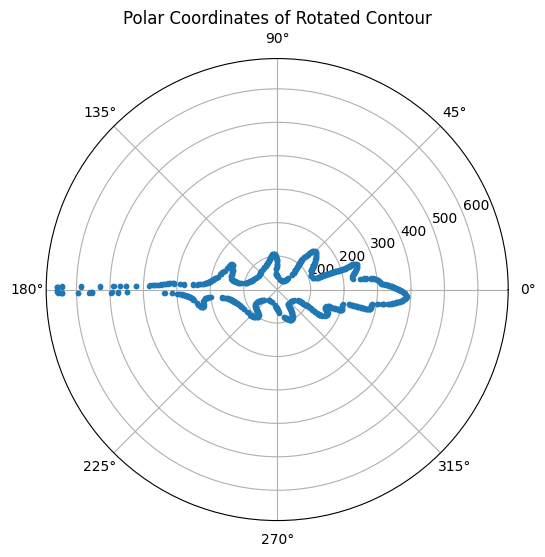

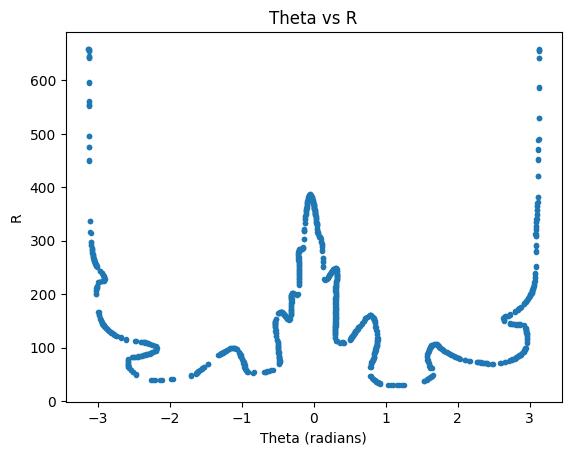

Angle before adjustment: 136.0737762451172


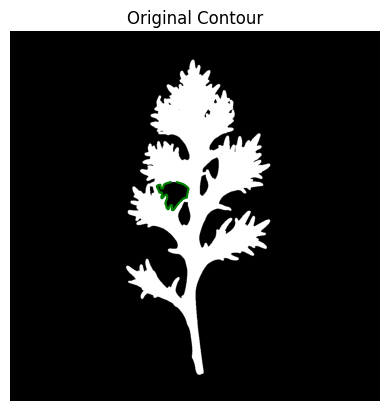

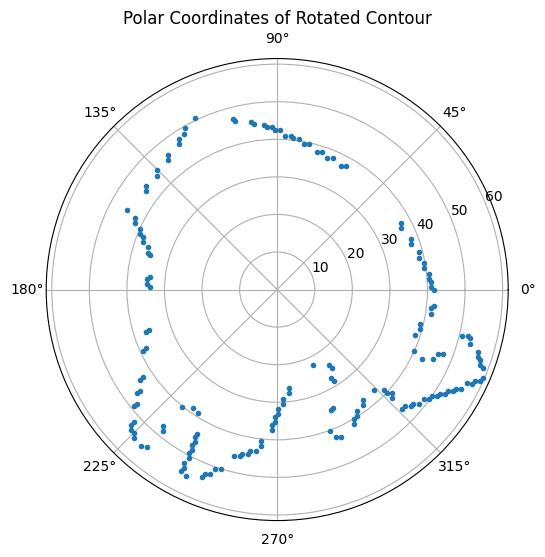

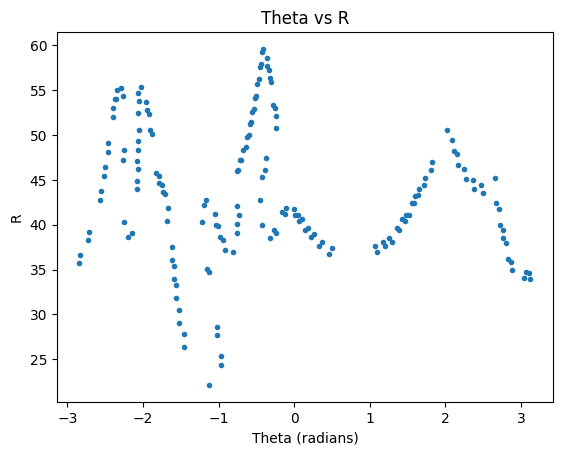

Angle before adjustment: 128.93959045410156


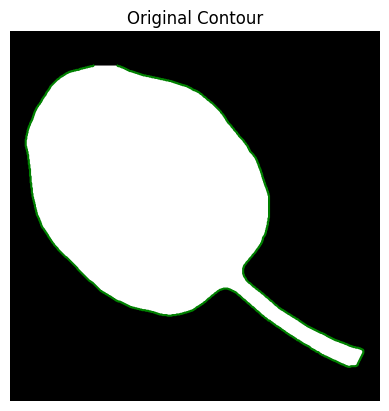

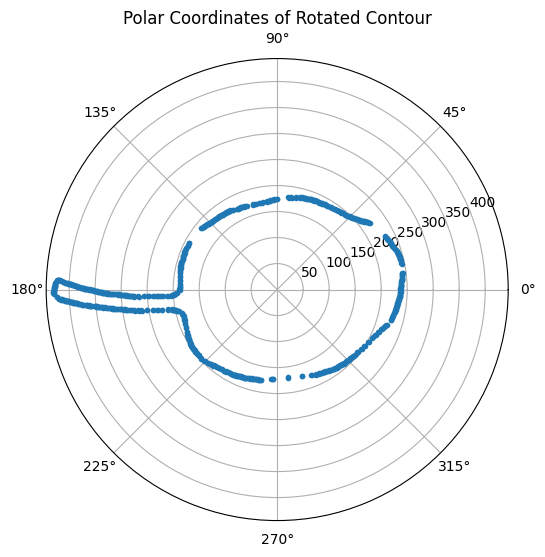

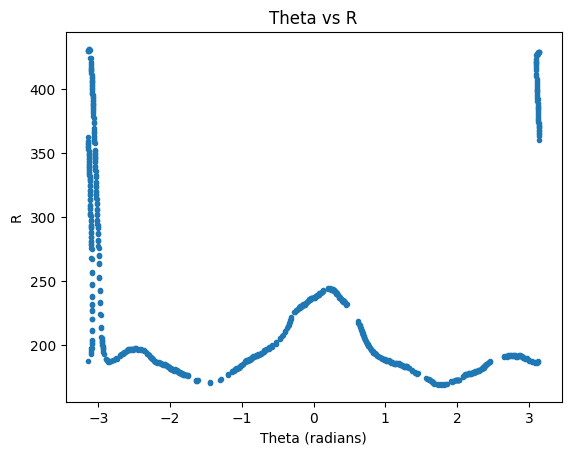

{'M': {'m00': 125570.0,
  'm10': 29190504.666666664,
  'm01': 33404206.833333332,
  'm20': 8339678908.333333,
  'm11': 8401421976.5,
  'm02': 10401651153.166666,
  'm30': 2722788811222.0,
  'm21': 2579714189981.3833,
  'm12': 2809571019294.75,
  'm03': 3604992623952.1504,
  'mu20': 1553937388.1080542,
  'mu11': 636146389.5388231,
  'mu02': 1515443984.5426865,
  'mu30': 61644674479.484375,
  'mu21': 65425526426.5014,
  'mu12': 53105480771.0871,
  'mu03': 31660497357.033203,
  'nu20': 0.0985511570532505,
  'nu11': 0.04034458738432737,
  'nu02': 0.09610989430398141,
  'nu30': 0.011032675076679236,
  'nu21': 0.011709341980944442,
  'nu12': 0.00950439789139011,
  'nu03': 0.005666344790618656},
 'angle': 38.93959045410156,
 'angles': (np.float32(0.4602682),
  np.float32(0.45454508),
  np.float32(0.4390185),
  np.float32(0.4332828),
  np.float32(0.4217995),
  np.float32(0.41605282),
  np.float32(0.40471488),
  np.float32(0.39896092),
  np.float32(0.38777286),
  np.float32(0.38201526),
  np.fl

In [2]:
# Load the image
image1 = cv2.imread("Wild Rocket image.jpg", cv2.IMREAD_GRAYSCALE)
image2 = cv2.imread("rocket2.jpeg", cv2.IMREAD_GRAYSCALE)
image3 = cv2.imread("rocket3.jpg", cv2.IMREAD_GRAYSCALE)
image4 = cv2.imread("rocket4.jpg", cv2.IMREAD_GRAYSCALE)
image5 = cv2.imread("spinach.jpg", cv2.IMREAD_GRAYSCALE)
process_image(image1)
process_image(image2)
process_image(image3)
process_image(image4)
process_image(image5)

